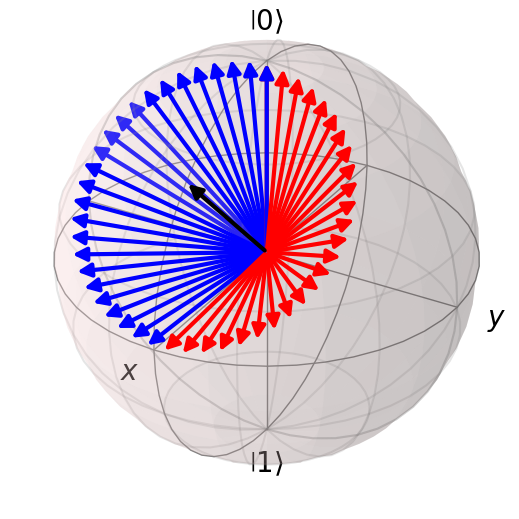

In [ ]:
from qutip import *
import numpy as np
import scipy
import matplotlib.colors
import scipy

#the gate
hadamard = qutip.gates.hadamard_transform()
sqrt_x = qutip.gates.rx(np.pi.4)
# the hamilton operator describing the evolution during the hadamard gate
hamilton = Qobj(scipy.linalg.logm(hadamard.data_as("ndarray")), dims=hadamard.dims) 

#create initial state vector
psi0 = (basis(2, 0)).unit()

# describing the gate as time evolution
def gate(t):
    return (-2*hamilton*t).expm()

# hadamard gate for t = 0.5
# In[1]: gate(0.5)
# Out[3]: 
# Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
# Qobj data =
# [[ 0.70710678  0.70710678]
#  [ 0.70710678 -0.70710678]]

# evolve the gate
n = 25
psi = [gate(t)*psi0 for t in np.linspace(0, 1., 2*n)]

# plotting the states. State evolution during the first hamadard gate is red. During second hadamard gate is blue
b = Bloch()
b.vector_color = [matplotlib.colors.to_rgba('r', alpha=i) for i in np.arange(n)/float(n)] + [matplotlib.colors.to_rgba('b', alpha=i) for i in np.arange(n)/float(n)]  + ['black']
b.add_states(psi)
b.add_states([(basis(2,0) + (basis(2,0) + basis(2,1)).unit()).unit()])

b.show()


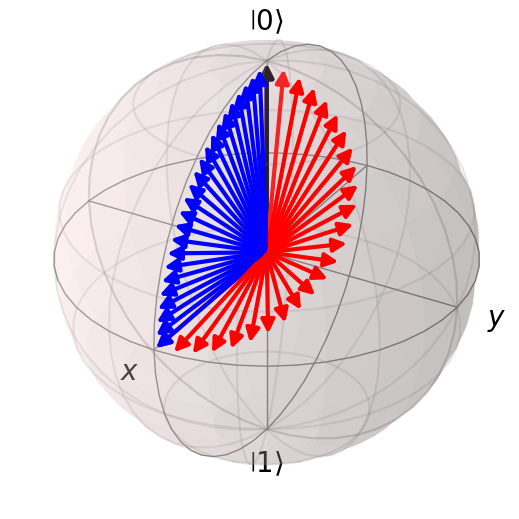

In [8]:
from qutip import *
import numpy as np
import scipy.linalg
import matplotlib.colors

# --- helpers ---------------------------------------------------------------

def hamiltonian_for_unitary(U: Qobj) -> Qobj:
    """
    Given a target unitary U, return a Hermitian effective Hamiltonian H_eff
    such that exp(-i H_eff * 1) ≈ U (principal matrix log).
    """
    # principal matrix logarithm
    L = scipy.linalg.logm(U.full())
    H = Qobj(-1j * L, dims=U.dims)
    # symmetrize to clean tiny numerical non-Hermiticity
    return (H + H.dag()) / 2

def make_evolution(U: Qobj):
    """
    Returns (H_eff, U(t)) where U(t) evolves from I at t=0 to target U at t=1.
    """
    H = hamiltonian_for_unitary(U)
    def U_of_t(t):
        return (-1j * H * t).expm()
    return H, U_of_t

# --- gates -----------------------------------------------------------------

# Hadamard
U_H = qutip.gates.hadamard_transform()

# sqrt(X) ≡ Rx(pi/2) up to a global phase (global phase is physically irrelevant)
theta = np.pi / 2.0
U_sqrtX = qutip.gates.ry(theta)

# build evolutions U_H(t), U_sqrtX(t) with t in [0, 1]
H_H,  UH_t  = make_evolution(U_H)
H_Xh, UXh_t = make_evolution(U_sqrtX)

# sanity-check: endpoints (should match targets up to global phase)
# print((UH_t(1) - U_H).norm())
# print((UXh_t(1) - U_sqrtX).norm())

# --- initial state ---------------------------------------------------------

psi0 = basis(2, 0)  # |0>

# --- evolve: first H, then sqrt(X) ----------------------------------------

n = 25  # number of steps per gate segment
ts = np.linspace(0.0, 1.0, 2*n)  # just for plotting density

# first segment: H from t∈[0,1]
psi_H_path = [UH_t(t) * psi0 for t in np.linspace(0.0, 1.0, n)]

# second segment: sqrt(X) from t∈[0,1], starting at end of first segment
psi_after_H = psi_H_path[-1]
psi_Xh_path = [UXh_t(t) * psi_after_H for t in np.linspace(0.0, 1.0, n)]

# full path for plotting
psi_all = psi_H_path + psi_Xh_path

# --- results you might want to inspect ------------------------------------

U_total = U_sqrtX * U_H          # overall unitary of the sequence
psi_final = psi_all[-1]          # final state after H then sqrt(X)

# Hadamard, sqrt(X), and total unitary matrices (optional prints)
# print("H:\n", U_H.full())
# print("sqrt(X):\n", U_sqrtX.full())
# print("U_total = sqrt(X) * H:\n", U_total.full())
# print("Final state ket:\n", psi_final.full())

# --- Bloch sphere plot -----------------------------------------------------

b = Bloch()

# color gradient: red for first segment, blue for second
reds  = [matplotlib.colors.to_rgba('r', alpha=i) for i in np.linspace(0.15, 1.0, n)]
blues = [matplotlib.colors.to_rgba('b', alpha=i) for i in np.linspace(0.15, 1.0, n)]
b.vector_color = reds + blues + ['black']  # final marker in black

# add the trajectory states
b.add_states(psi_all)

# add some helpful reference states/markers (final state in black)
b.add_states([psi_final])

# you can also add the intermediate boundary states as big markers:
# b.add_states([psi0, psi_after_H, psi_final])

b.show()


||U(t=1) - target|| for sanity checks:
1.8636776422777956e-15 2.82842712474619 1.5307337294603593
U_total:
 [[ 7.66747578e-17-4.91193151e-17j  9.23879533e-01-3.82683432e-01j]
 [ 9.23879533e-01+3.82683432e-01j -5.73410164e-17-4.56441476e-17j]]
Final state ket:
 [[9.23879533e-01+4.16333634e-16j]
 [5.55111512e-16-3.82683432e-01j]]


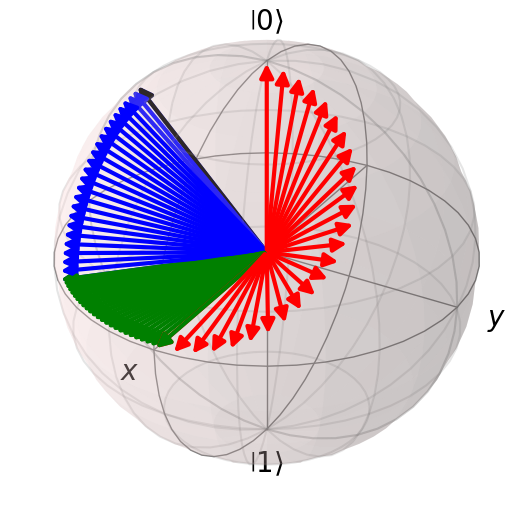

In [12]:
from qutip import *
import numpy as np
import scipy.linalg
import matplotlib.colors

# --- helpers ---------------------------------------------------------------

def hamiltonian_for_unitary(U: Qobj) -> Qobj:
    """
    Given a target unitary U, return a Hermitian effective Hamiltonian H_eff
    such that exp(-i H_eff * 1) ≈ U (principal matrix log).
    """
    L = scipy.linalg.logm(U.full())       # principal matrix logarithm
    H = Qobj(-1j * L, dims=U.dims)        # convert to Hermitian generator
    return (H + H.dag()) / 2              # symmetrize to clean numerics

def make_evolution(U: Qobj):
    """
    Returns (H_eff, U(t)) with t in [0,1] evolving from I to U.
    """
    H = hamiltonian_for_unitary(U)
    def U_of_t(t):
        return (-1j * H * t).expm()
    return H, U_of_t

# --- gates -----------------------------------------------------------------

# Hadamard
U_H = qutip.gates.hadamard_transform()

# sqrt(Y) ≡ Ry(pi/2) up to global phase
U_sqrtY = qutip.gates.ry(np.pi / 2.0)

# Rz(pi/4)
U_Rz = qutip.gates.rz(np.pi / 4.0)

# evolutions for each gate segment, t ∈ [0,1]
_, UH_t   = make_evolution(U_H)
_, UYh_t  = make_evolution(U_sqrtY)
_, URz_t  = make_evolution(U_Rz)

# --- initial state ---------------------------------------------------------

psi0 = basis(2, 0)  # |0>

# --- evolve sequentially: H → sqrt(Y) → Rz(pi/4) --------------------------

n = 25  # steps per segment

# segment 1: H
psi_seg1 = [UH_t(t) * psi0 for t in np.linspace(0.0, 1.0, n)]
psi_after_H = psi_seg1[-1]

# segment 3: Rz(pi/4)
psi_seg3 = [URz_t(t) * psi_after_H for t in np.linspace(0.0, 1.0, n)]
psi_after_rz = psi_seg3[-1]

# segment 2: sqrt(Y)
psi_seg2 = [UYh_t(t) * psi_after_rz for t in np.linspace(0.0, 1.0, n)]
psi_final = psi_seg2[-1]

psi_all = psi_seg1 + psi_seg2 + psi_seg3

# overall unitary (for reference/verification)
U_total = U_Rz * U_sqrtY * U_H
print("||U(t=1) - target|| for sanity checks:")
print((UH_t(1) - U_H).norm(), (UYh_t(1) - U_sqrtY).norm(), (URz_t(1) - U_Rz).norm())
print("U_total:\n", U_total.full())
print("Final state ket:\n", psi_final.full())

# --- Bloch sphere ----------------------------------------------------------

b = Bloch()

# color gradients: red (H), blue (√Y), green (Rz)
reds   = [matplotlib.colors.to_rgba('r', alpha=a) for a in np.linspace(0.15, 1.0, n)]
blues  = [matplotlib.colors.to_rgba('b', alpha=a) for a in np.linspace(0.15, 1.0, n)]
greens = [matplotlib.colors.to_rgba('g', alpha=a) for a in np.linspace(0.15, 1.0, n)]
b.vector_color = reds + blues + greens + ['black']  # final marker in black

b.add_states(psi_all)
b.add_states([psi_final])  # final state marker
# Optionally mark boundaries:
# b.add_states([psi0, psi_after_H, psi_after_Yh, psi_final])

b.show()
